In [8]:
import pandas as pd 
import numpy as np
import duckdb 
import logging 
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s',
    filename='visualization.log'
)
logger = logging.getLogger(__name__)

In [5]:
### load duckdb table into pandas dfs 
con = None 
try: 
    # create and verify connection 
    con = duckdb.connect(database='project1.db', read_only=False) 
    logger.info("Connected to duckdb instance.") 

    # inserting tables 
    df = con.execute(f"""
        SELECT * FROM results_df;
    """).fetchdf()
    
    logger.info("results_df loaded into pandas dataframes")

except Exception as e:
    logger.error(f"An error occurred: {e}")

finally:
    if con:
        con.close()
        logger.info("Duckdb connection closed.")

In [15]:
df2 = df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Value")

df2

,Model,Metric,Value
0,Linear_Regression,Overall_RMSE,890.8464
1,Random_Forest,Overall_RMSE,547.0304
2,Linear_Regression,Normal_RMSE,868.4940
3,Random_Forest,Normal_RMSE,524.8446
4,Linear_Regression,Extreme_RMSE,911.4645
5,Random_Forest,Extreme_RMSE,567.1979
6,Linear_Regression,Overall_MAE,699.2240
7,Random_Forest,Overall_MAE,395.3623
8,Linear_Regression,Normal_MAE,687.3566
9,Random_Forest,Normal_MAE,377.9069


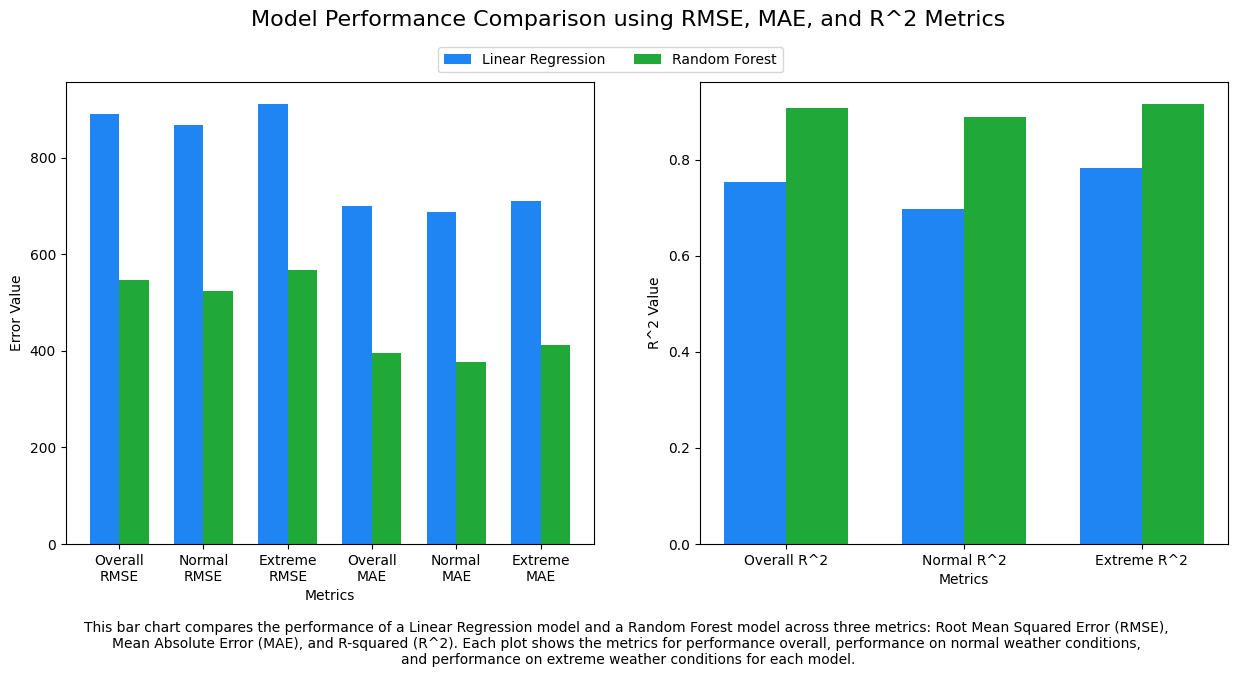

In [91]:
# create visualization 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# split data into rmse+mae and r2
errordf = df2[df2['Metric'].str.contains('MAE|RMSE')]
r2df = df2[df2['Metric'].str.contains('R2')]

# get metrics 
e_metrics = errordf['Metric'].unique()
r2_metrics = r2df['Metric'].unique()

# split by model 
lr_error_values = [errordf[(errordf["Model"]=="Linear_Regression") & (errordf["Metric"]==m)]["Value"].values[0] for m in e_metrics]
rf_error_values = [errordf[(errordf["Model"]=="Random_Forest") & (errordf["Metric"]==m)]["Value"].values[0] for m in e_metrics]

lr_r2_values = [r2df[(r2df["Model"]=="Linear_Regression") & (r2df["Metric"]==m)]["Value"].values[0] for m in r2_metrics]
rf_r2_values = [r2df[(r2df["Model"]=="Random_Forest") & (r2df["Metric"]==m)]["Value"].values[0] for m in r2_metrics]

# x positions 
x1 = np.arange(len(e_metrics))
x2 = np.arange(len(r2_metrics))
width = 0.35 

# plot rmse and mae
ax1.bar(x1 - width/2, lr_error_values, width, label="Linear Regression", color='#1f85f2')
ax1.bar(x1 + width/2, rf_error_values, width, label="Random Forest", color='#20a839')
ax1.set_xticks(x1)
# making x labels more readable
e_metrics = ['Overall\nRMSE', 'Normal\nRMSE', 'Extreme\nRMSE', 'Overall\nMAE', 'Normal\nMAE', 'Extreme\nMAE']
ax1.set_xticklabels(e_metrics, ha="center")
ax1.set_ylabel("Error Value")
ax1.set_xlabel('Metrics')

# plot r2 
ax2.bar(x2 - width/2, lr_r2_values, width, label="Linear Regression", color='#1f85f2')
ax2.bar(x2 + width/2, rf_r2_values, width, label="Random Forest", color='#20a839')
ax2.set_xticks(x2)
# making x labels more readable 
r2_metrics = ['Overall R^2', 'Normal R^2', 'Extreme R^2']
ax2.set_xticklabels(r2_metrics, ha="center")
ax2.set_ylabel("R^2 Value")
ax2.set_xlabel('Metrics')

# title, legend, caption
fig.suptitle("Model Performance Comparison using RMSE, MAE, and R^2 Metrics", fontsize=16, x=0.5, y=1.0)
plt.legend(loc='best', bbox_to_anchor=(0.17, 1.09), ncols=2)
fig.text(0.5, -0.09, 
         "This bar chart compares the performance of a Linear Regression model and a Random Forest model across three metrics: Root Mean Squared Error (RMSE), \nMean Absolute Error (MAE), and R-squared (R^2). Each plot shows the metrics for performance overall, performance on normal weather conditions, \nand performance on extreme weather conditions for each model.", 
         ha='center')

# save as png 
plt.savefig('model_comparison.png', bbox_inches='tight')

plt.show() 